In [32]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import mne
mne.set_log_level('ERROR')
warnings.filterwarnings("ignore")
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [5]:
def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

In [6]:
def listar_archivos_train(base_path="./StudyF"):
    """
    Recorre todas las carpetas de sujetos y sesiones, y devuelve la lista completa 
    de rutas a archivos EDF de entrenamiento (Train*.edf).
    
    Returns:
        lista_rutas (list): Lista con rutas absolutas de archivos EDF de entrenamiento.
    """
    lista_rutas = []

    for sujeto in os.listdir(base_path):
        path_sujeto = os.path.join(base_path, sujeto)
        if not os.path.isdir(path_sujeto):
            continue  # Saltar si no es carpeta

        for sesion in ["SE001", "SE002", "SE003"]:
            path_sesion = os.path.join(path_sujeto, sesion, "Train", "CBCol")
            if not os.path.exists(path_sesion):
                continue  # Saltar si no existe la carpeta de la sesión

            for archivo in os.listdir(path_sesion):
                if archivo.endswith(".edf") and "Train" in archivo:
                    ruta_completa = os.path.join(path_sesion, archivo)
                    lista_rutas.append(ruta_completa)

    return lista_rutas

In [9]:
def cargar_edf_sujeto(sujeto_id, archivos_train):
    """
    Filtra y carga todos los archivos .edf de entrenamiento correspondientes a un sujeto.
    
    Args:
        sujeto_id (str): ID del sujeto (e.g., "F_03")
        archivos_train (list): Lista de rutas absolutas a archivos .edf (output de listar_archivos_train)
    
    Returns:
        df_concatenado (pd.DataFrame): DataFrame con todos los datos de entrenamiento del sujeto
        raw_info (mne.io.Raw.info): Información de sampling (del primer archivo cargado)
    """
    archivos_sujeto = [f for f in archivos_train if os.path.basename(f).startswith(sujeto_id)]
    if not archivos_sujeto:
        raise ValueError(f"No se encontraron archivos EDF para el sujeto {sujeto_id}")
    
    dfs = []
    raw_info = None
    
    for i, archivo in enumerate(sorted(archivos_sujeto)):
        raw = mne.io.read_raw_edf(archivo, preload=True, verbose=False)
        fs = raw.info['sfreq']  # frecuencia de muestreo
        df = raw.to_data_frame()
        # Definir bandas según sujeto
        if sujeto_id in ["F_05", "F_06", "F_07", "F_08"]:
            lowcut, highcut = 0.1, 30
        else:
            lowcut, highcut = 0.5, 30
        # Aplicar filtro solo a columnas EEG
        eeg_cols = [col for col in df.columns if col.startswith('EEG_')]
        for col in eeg_cols:
            df[col] = butter_bandpass_filter(df[col].values, lowcut, highcut, fs)
        dfs.append(df)
        if raw_info is None:
            raw_info = raw.info  # Guardamos solo una vez la info del sampling
    
    df_concatenado = pd.concat(dfs, ignore_index=True)
    return df_concatenado, raw_info

In [10]:
def obtener_epochs_target_multicanal(sujeto_id, canales_eeg, fs=256, base_path="./StudyF"):
    """
    Carga todos los archivos de entrenamiento de un sujeto, encuentra los eventos 
    StimulusType == 1 y StimulusBegin == 1, y extrae las ventanas EEG alrededor 
    de esos eventos, para múltiples canales EEG.

    Args:
        sujeto_id (str): ID del sujeto (e.g., 'F_03')
        canales_eeg (list): Lista con nombres de canales EEG a usar (e.g., ['EEG_Pz', 'EEG_Cz'])
        fs (int): Frecuencia de muestreo (Hz). Por defecto 256.
        base_path (str): Ruta base donde están los datos EDF

    Returns:
        epochs_target (np.ndarray): Matriz de epocas shape (n_eventos, n_canales, muestras)
        epochs_nontarget (np.ndarray): Matriz de epocas no-target con misma forma
    """
    # Paso 1: Obtener archivos del sujeto
    archivos = listar_archivos_train(base_path)
    df, raw_info = cargar_edf_sujeto(sujeto_id, archivos)

    # Paso 2: Detectar eventos relevantes
    stim_type = (df['StimulusType'].to_numpy() == 1000000.0)
    stim_begin = (df['StimulusBegin'].to_numpy() == 1000000.0)
    joint_signal = stim_begin  # versión v2
    edges = np.diff(joint_signal.astype(int), prepend=0)
    event_indices = np.where(edges == 1)[0]

    # Paso 3: Epocamiento multicanal
    pre = 0
    post = int(0.8 * fs)
    epoch_len = pre + post
    n_canales = len(canales_eeg)

    epochs_target = []
    epochs_nontarget = []

    for t in event_indices:
        if t - pre >= 0 and t + post < len(df):
            epoca = np.zeros((n_canales, epoch_len))
            for i, canal in enumerate(canales_eeg):
                señal = df[canal].values
                epoca[i, :] = señal[t - pre : t + post]
            if stim_type[t]:  # target
                epochs_target.append(epoca)
            else:
                epochs_nontarget.append(epoca)

    return np.array(epochs_target), np.array(epochs_nontarget)

In [13]:
def convertir_a_vectores_caracteristicas(epochs_target, epochs_nontarget):
    """
    Convierte épocas multicanal a vectores de características para machine learning.

    Args:
        epochs_target (np.ndarray): shape (n_target, n_canales, n_muestras)
        epochs_nontarget (np.ndarray): shape (n_nontarget, n_canales, n_muestras)

    Returns:
        X (np.ndarray): features concatenadas shape (n_trials, n_canales * n_muestras)
        y (np.ndarray): etiquetas binaria shape (n_trials,)
    """
    n_target = epochs_target.shape[0]
    n_nontarget = epochs_nontarget.shape[0]
    feature_dim = epochs_target.shape[1] * epochs_target.shape[2]

    # Flatten
    features_target = epochs_target.reshape(n_target, feature_dim)
    features_nontarget = epochs_nontarget.reshape(n_nontarget, feature_dim)

    # Concatenar
    X = np.vstack([features_target, features_nontarget])
    y = np.array([1] * n_target + [0] * n_nontarget)

    return X, y

In [18]:
def stepwise_selection(X, y, 
                       initial_list=[], 
                       threshold_in=0.01, 
                       threshold_out = 0.05, 
                       verbose=True):
    """ The original author of stepwise_selection is: https://datascience.stackexchange.com/users/24162/david-dale
    It perform a forward-backward feature selection 
    based on p-value from statsmodels.api.OLS
    Arguments:
        X - pandas.DataFrame with candidate features
        y - list-like with the target
        initial_list - list of features to start with (column names of X)
        threshold_in - include a feature if its p-value < threshold_in
        threshold_out - exclude a feature if its p-value > threshold_out
        verbose - whether to print the sequence of inclusions and exclusions
    Returns: list of selected features 
    Always set threshold_in < threshold_out to avoid infinite looping.
    See https://en.wikipedia.org/wiki/Stepwise_regression for the details
    """
    included = list(initial_list)
    while True:
        changed=False
        # forward step
        excluded = list(set(X.columns)-set(included))
        new_pval = pd.Series(index=excluded)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included+[new_column]]))).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed=True
            if verbose:
                print('Add  {:30} with p-value {:.6}'.format(best_feature, best_pval))

        # backward step
        model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
        # use all coefs except intercept
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max() # null if pvalues is empty
        if worst_pval > threshold_out:
            changed=True
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            if verbose:
                print('Drop {:30} with p-value {:.6}'.format(worst_feature, worst_pval))
        if not changed:
            break
    return included

Add                              52 with p-value 5.0726e-24
Add                              95 with p-value 7.25517e-19
Add                             278 with p-value 4.16845e-15
Add                             482 with p-value 1.04964e-29
Add                             250 with p-value 8.96426e-23
Add                             455 with p-value 1.015e-27
Add                              47 with p-value 2.3123e-28
Drop                            250 with p-value 0.755979
Add                             388 with p-value 6.45144e-14
Add                             113 with p-value 9.89837e-14
Add                             544 with p-value 5.68179e-10
Add                             339 with p-value 4.65725e-20
Add                             261 with p-value 1.20859e-09
Add                             184 with p-value 7.13144e-08
Add                             564 with p-value 7.11386e-09
Add                             473 with p-value 1.14038e-06
Add                            

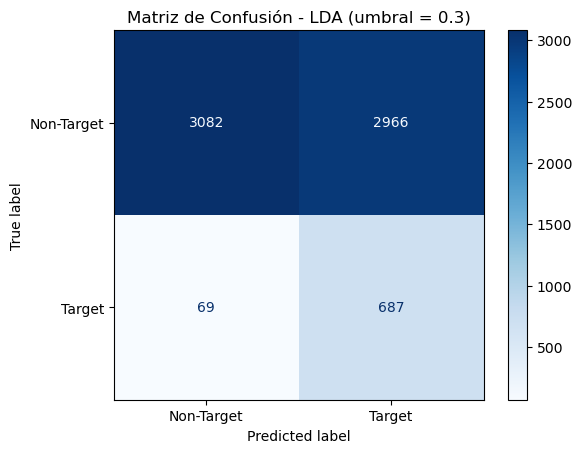

In [33]:
# ===== PASO 1: Cargar épocas multicanal =====
sujeto_id = 'F_03'
canales = ['EEG_Pz', 'EEG_Cz', 'EEG_Oz']
epochs_target, epochs_nontarget = obtener_epochs_target_multicanal(sujeto_id, canales)

# ===== PASO 2: Convertir a vectores de características =====
X, y = convertir_a_vectores_caracteristicas(epochs_target, epochs_nontarget)
X_df = pd.DataFrame(X, columns=np.arange(X.shape[1]))

# ===== PASO 3: Selección de características =====
selected_features = stepwise_selection(X_df, y, threshold_in=0.01, threshold_out=0.05, verbose=True)
X_selected = X_df[selected_features].to_numpy()

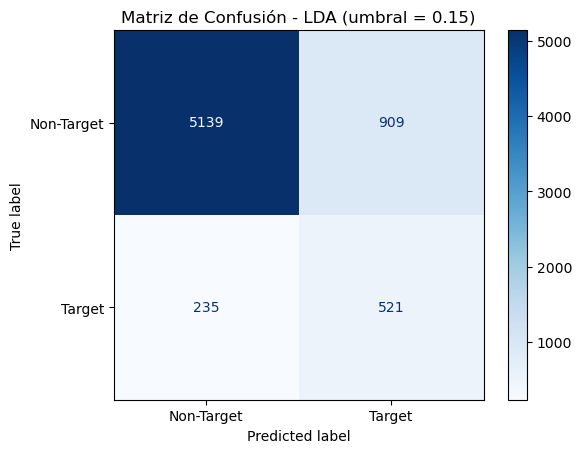

In [51]:
# ===== PASO 5: Entrenar modelo LDA =====
lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
lda.fit(X_selected, y)

# ===== PASO 6: Predecir sobre todo el conjunto original con umbral ajustado =====
y_proba = lda.predict_proba(X_selected)[:, 1]
threshold = 0.15
y_pred_adjusted = (y_proba >= threshold).astype(int)

# ===== PASO 7: Matriz de confusión =====
cm = confusion_matrix(y, y_pred_adjusted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Target", "Target"])
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Matriz de Confusión - LDA (umbral = {threshold})")
plt.show()